# Thesis Notebook — Stage 2: Word Generation and Qwen-Based Correction

This notebook performs the second stage of the thesis system. It loads the trained Stage 1 EMG/IMU letter classifier, predicts ASL fingerspelling letter sequences, combines the predicted letters into raw words, applies lexicon-based correction, and then applies LLM-based correction using **Qwen2.5-7B-Instruct**.

**Important:** Run the Stage 1 notebook first so that the trained model and normalization files exist.

**Required files from Stage 1**

- `stage1_augmented_split1_model.keras`
- `stage1_augmented_split1_mean.npy`
- `stage1_augmented_split1_std.npy`
- `stage1_label_map.json`, if available

**Main output files**

- `stage2_results.csv`
- `stage2_qwen_correction_results_final.csv`
- `stage2_summary_latest.csv`

**Expanded validation:** the original 28 target words have been increased to **100 target words**. The final evaluation uses **20 trials per word**, giving **2,000 word-level trials**.

**Evaluation scope:** the target words are included in the correction vocabulary. Therefore, this experiment represents a **closed-vocabulary word-correction setting**. Each word is constructed from independently selected isolated EMG/IMU letter recordings; it is not continuous EMG word recognition.


## Kaggle/Colab note

This version is adjusted for Kaggle. It expects the raw dataset folder `Dataset_1_Converted` and the saved Stage 1 files:

- `stage1_augmented_split1_model.keras`
- `stage1_augmented_split1_mean.npy`
- `stage1_augmented_split1_std.npy`
- `stage1_label_map.json`

Run Stage 1 first in the same Kaggle session, or upload the Stage 1 output files as a Kaggle Dataset and add that dataset to this notebook.

## 1. Local path setup, imports, and configuration

In [9]:
from pathlib import Path
import os
import re
import json
import random
import shutil
import zipfile
from collections import defaultdict

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model

# ============================================================
# Robust Kaggle/New Notebook path setup
# ============================================================

ON_KAGGLE = Path("/kaggle/input").exists()
ON_COLAB = Path("/content").exists() and not ON_KAGGLE

if ON_KAGGLE:
    INPUT_BASE = Path("/kaggle/input")
    WORKING_BASE = Path("/kaggle/working")
    BASE_DIR = WORKING_BASE / "stage2_outputs"
elif ON_COLAB:
    INPUT_BASE = Path("/content")
    WORKING_BASE = Path("/content")
    BASE_DIR = WORKING_BASE / "stage2_outputs"
else:
    INPUT_BASE = Path(".").resolve()
    WORKING_BASE = Path(".").resolve()
    BASE_DIR = WORKING_BASE / "Metadata"

BASE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
USE_ORIENTATION = False
TOP_K = 3

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def list_top_level_inputs():
    print("Input folders/files available:")
    if INPUT_BASE.exists():
        for item in sorted(INPUT_BASE.iterdir()):
            print(" -", item)
    else:
        print("No input base found:", INPUT_BASE)


def maybe_extract_zip_for(target_keyword, extract_dir_name):
    """
    Looks for a zip file that contains target_keyword and extracts it once.
    This helps when Stage 1 outputs or Dataset_1_Converted were uploaded as a zip.
    """
    extract_dir = BASE_DIR / extract_dir_name
    marker_file = extract_dir / ".extracted"

    if marker_file.exists():
        return extract_dir

    zip_candidates = []
    search_roots = [INPUT_BASE, WORKING_BASE, Path(".").resolve()]

    for root in search_roots:
        if not root.exists():
            continue
        zip_candidates.extend(list(root.rglob("*.zip")))

    for zip_path in zip_candidates:
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                names = zf.namelist()
                if any(target_keyword in name for name in names):
                    print(f"Extracting {zip_path} because it contains {target_keyword} ...")
                    extract_dir.mkdir(parents=True, exist_ok=True)
                    zf.extractall(extract_dir)
                    marker_file.write_text("done")
                    return extract_dir
        except Exception as e:
            print("Could not inspect zip:", zip_path, e)

    return None


def find_dataset_root():
    """
    Finds Dataset_1_Converted in /kaggle/input, /kaggle/working, or extracted zips.
    """
    search_roots = [
        INPUT_BASE,
        WORKING_BASE,
        BASE_DIR,
        Path(".").resolve()
    ]

    # First search normal folders
    for root in search_roots:
        if not root.exists():
            continue

        for path in root.rglob("Dataset_1_Converted"):
            if path.is_dir():
                user_folders = [
                    p for p in path.iterdir()
                    if p.is_dir() and p.name.lower().startswith("user")
                ]
                if len(user_folders) > 0:
                    return path

    # If not found, try extracting a zip containing Dataset_1_Converted
    extracted = maybe_extract_zip_for("Dataset_1_Converted", "extracted_dataset_zip")

    if extracted is not None:
        for path in extracted.rglob("Dataset_1_Converted"):
            if path.is_dir():
                user_folders = [
                    p for p in path.iterdir()
                    if p.is_dir() and p.name.lower().startswith("user")
                ]
                if len(user_folders) > 0:
                    return path

    return None


def find_stage1_base_dir():
    """
    Finds the directory containing Stage 1 model and normalisation files.
    """
    required_model_name = "stage1_augmented_split1_model.keras"

    search_roots = [
        INPUT_BASE,
        WORKING_BASE,
        BASE_DIR,
        Path(".").resolve()
    ]

    # First search normal folders
    for root in search_roots:
        if not root.exists():
            continue

        matches = list(root.rglob(required_model_name))

        if len(matches) > 0:
            # Prefer shortest path, usually the cleanest dataset folder
            matches = sorted(matches, key=lambda p: len(str(p)))
            return matches[0].parent

    # If not found, try extracting a zip containing Stage 1 model
    extracted = maybe_extract_zip_for(required_model_name, "extracted_stage1_zip")

    if extracted is not None:
        matches = list(extracted.rglob(required_model_name))
        if len(matches) > 0:
            matches = sorted(matches, key=lambda p: len(str(p)))
            return matches[0].parent

    return None


list_top_level_inputs()

ROOT_PATH = find_dataset_root()

if ROOT_PATH is None:
    raise FileNotFoundError(
        "Could not find Dataset_1_Converted. "
        "In Kaggle, click Add Data and attach your Dataset_1_Converted dataset or zip."
    )

STAGE1_DIR = find_stage1_base_dir()

if STAGE1_DIR is None:
    raise FileNotFoundError(
        "Could not find stage1_augmented_split1_model.keras. "
        "In Kaggle, click Add Data and attach your Stage 1 output files or zip."
    )

MODEL_PATH = STAGE1_DIR / "stage1_augmented_split1_model.keras"
MEAN_PATH = STAGE1_DIR / "stage1_augmented_split1_mean.npy"
STD_PATH = STAGE1_DIR / "stage1_augmented_split1_std.npy"
LABEL_MAP_PATH = STAGE1_DIR / "stage1_label_map.json"

required_paths = [MODEL_PATH, MEAN_PATH, STD_PATH, LABEL_MAP_PATH]
missing = [str(p) for p in required_paths if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Some required Stage 1 files are missing:\n" + "\n".join(missing)
    )

ROOT = str(ROOT_PATH)

with open(LABEL_MAP_PATH, "r") as f:
    label_map = json.load(f)

# Ensure dictionary values are integers after JSON loading.
label_map = {k: int(v) for k, v in label_map.items()}
inv_label_map = {v: k for k, v in label_map.items()}

print("\nTensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Running on Kaggle:", ON_KAGGLE)
print("Running on Colab:", ON_COLAB)

print("\nDataset ROOT:")
print(ROOT)

print("\nStage 1 file directory:")
print(STAGE1_DIR)

print("\nWritable Stage 2 output directory:")
print(BASE_DIR)

print("\nRequired Stage 1 files:")
for p in required_paths:
    print(p.name, "FOUND", "->", p)


Input folders/files available:
 - /kaggle/input/datasets

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Running on Kaggle: True
Running on Colab: False

Dataset ROOT:
/kaggle/input/datasets/sujitks/dataset-1-converted-2/Dataset_1_Converted

Stage 1 file directory:
/kaggle/input/datasets/sujitks/metadata

Writable Stage 2 output directory:
/kaggle/working/stage2_outputs

Required Stage 1 files:
stage1_augmented_split1_model.keras FOUND -> /kaggle/input/datasets/sujitks/metadata/stage1_augmented_split1_model.keras
stage1_augmented_split1_mean.npy FOUND -> /kaggle/input/datasets/sujitks/metadata/stage1_augmented_split1_mean.npy
stage1_augmented_split1_std.npy FOUND -> /kaggle/input/datasets/sujitks/metadata/stage1_augmented_split1_std.npy
stage1_label_map.json FOUND -> /kaggle/input/datasets/sujitks/metadata/stage1_label_map.json


## 2. Load trained Stage 1 model and normalization parameters

In [10]:
model = load_model(MODEL_PATH)
mean = np.load(MEAN_PATH)
std = np.load(STD_PATH)

# Use the exact input length expected by the saved Stage 1 model.
# This avoids mismatch between Stage 1 training and Stage 2 prediction.
model_input_shape = model.input_shape
TARGET_LEN = model_input_shape[1] if model_input_shape[1] is not None else 100
TARGET_LEN = int(TARGET_LEN)

print("Loaded Stage 1 model and scaler.")
print("Model input shape:", model_input_shape)
print("TARGET_LEN used for Stage 2 prediction:", TARGET_LEN)
print("Mean shape:", mean.shape)
print("Std shape:", std.shape)


Loaded Stage 1 model and scaler.
Model input shape: (None, 100, 14)
TARGET_LEN used for Stage 2 prediction: 100
Mean shape: (1, 14)
Std shape: (1, 14)


## 3. Helper functions for loading samples and predicting letters

In [11]:
def parse_label(filename):
    """
    Extracts letter label from filenames like:
    alphabet_a_right.json, alphabet_b_right.json, etc.
    """
    m = re.search(r"alphabet_([a-z])_right", filename.lower())
    return m.group(1).upper() if m else None


def resample_sequence(seq, target_len=100):
    """Resample a variable-length EMG+IMU sequence to a fixed length."""
    old_len = seq.shape[0]

    old_idx = np.linspace(0.0, 1.0, old_len)
    new_idx = np.linspace(0.0, 1.0, target_len)

    out = np.stack([
        np.interp(new_idx, old_idx, seq[:, j])
        for j in range(seq.shape[1])
    ], axis=1)

    return out.astype(np.float32)


def load_json_sample(path, use_orientation=False):
    with open(path, "r") as f:
        data = json.load(f)

    emg = np.array(data["emg"]["data"], dtype=np.float32)
    imu = data["imu"]["data"]

    acc = np.array([x["acceleration"] for x in imu], dtype=np.float32)
    gyro = np.array([x["gyroscope"] for x in imu], dtype=np.float32)
    ori = np.array([x["orientation"] for x in imu], dtype=np.float32)

    T = min(len(emg), len(gyro), len(acc), len(ori))

    emg = emg[:T]
    gyro = gyro[:T]
    acc = acc[:T]
    ori = ori[:T]

    if use_orientation:
        X = np.concatenate([emg, gyro, acc, ori], axis=1)
    else:
        X = np.concatenate([emg, gyro, acc], axis=1)

    X = resample_sequence(X, target_len=TARGET_LEN)
    X = ((X - mean) / std).astype(np.float32)

    return X


def predict_letter_from_file(path, top_k=3):
    X = load_json_sample(path, use_orientation=USE_ORIENTATION)

    probs = model.predict(np.expand_dims(X, axis=0), verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    top_letters = [inv_label_map[i] for i in top_idx]
    top_probs = [float(probs[i]) for i in top_idx]

    return {
        "path": path,
        "top1_letter": top_letters[0],
        "top1_prob": top_probs[0],
        "top_letters": top_letters,
        "top_probs": top_probs
    }

print("Helper functions loaded.")


Helper functions loaded.


## 4. Group raw sample files by ASL letter

In [12]:
files_by_letter = defaultdict(list)

for user in sorted(os.listdir(ROOT)):
    user_path = os.path.join(ROOT, user)

    if not os.path.isdir(user_path):
        continue

    for fname in sorted(os.listdir(user_path)):
        if not fname.endswith(".json"):
            continue

        letter = parse_label(fname)

        if letter is None:
            continue

        files_by_letter[letter].append(os.path.join(user_path, fname))

for letter in sorted(files_by_letter):
    print(letter, len(files_by_letter[letter]))

A 45
B 45
C 45
D 45
E 45
F 45
G 46
H 48
I 46
J 45
K 47
L 45
M 46
N 46
O 45
P 46
Q 47
R 46
S 45
T 45
U 45
V 46
W 46
X 45
Y 47
Z 46


## 5. Test one single-letter prediction

In [13]:
sample_file = files_by_letter["H"][0]

result = predict_letter_from_file(sample_file, top_k=3)

print("Top-1:", result["top1_letter"], result["top1_prob"])
print("Top-3:", list(zip(result["top_letters"], result["top_probs"])))

Top-1: H 0.9993636012077332
Top-3: [('H', 0.9993636012077332), ('G', 0.0006005881004966795), ('J', 3.0148003133945167e-05)]


## 6. Build raw word from predicted letter samples

In [15]:
def predict_word_from_target_word(word, top_k=3):
    word = word.upper()

    letter_results = []

    for ch in word:
        chosen_file = random.choice(files_by_letter[ch])

        pred = predict_letter_from_file(chosen_file, top_k=top_k)
        pred["true_letter"] = ch

        letter_results.append(pred)

    raw_top1 = "".join([x["top1_letter"] for x in letter_results])

    return {
        "target_word": word,
        "raw_top1_word": raw_top1,
        "letter_results": letter_results
    }


word_result = predict_word_from_target_word("HELLO", top_k=3)

print("Target:", word_result["target_word"])
print("Raw top1:", word_result["raw_top1_word"])

for i, x in enumerate(word_result["letter_results"], start=1):
    print(
        i,
        x["true_letter"],
        list(zip(x["top_letters"], [round(p, 4) for p in x["top_probs"]]))
    )

Target: HELLO
Raw top1: HELLO
1 H [('H', 0.9995), ('K', 0.0003), ('J', 0.0002)]
2 E [('E', 0.9836), ('F', 0.0112), ('W', 0.0037)]
3 L [('L', 0.9894), ('Y', 0.0048), ('M', 0.0019)]
4 L [('L', 0.9991), ('P', 0.0006), ('X', 0.0002)]
5 O [('O', 0.9983), ('N', 0.0007), ('D', 0.0004)]


## 7. Lexicon-based word correction

In [16]:
VOCAB = [
    "HELLO", "WORLD", "HOUSE", "WATER", "APPLE", "BREAD", "PHONE", "TRAIN",
    "SCHOOL", "PERSON", "MOTHER", "FATHER", "SISTER", "BROTHER", "FRIEND", "MONEY",
    "WINDOW", "DOCTOR", "NURSE", "MODEL", "PYTHON", "NEPAL", "SYDNEY", "THESIS",
    "SYSTEM", "SECURITY", "TEXT", "VOICE", "FAMILY", "STUDENT", "TEACHER", "COLLEGE",
    "UNIVERSITY", "COMPUTER", "LANGUAGE", "SIGNAL", "LETTER", "WORD", "SENTENCE", "RESULT",
    "METHOD", "PROJECT", "RESEARCH", "SCIENCE", "HEALTH", "HOSPITAL", "PATIENT", "MEDICINE",
    "CARE", "WORK", "SHIFT", "NIGHT", "MORNING", "EVENING", "MARKET", "SHOP",
    "STORE", "OFFICE", "MEETING", "EMAIL", "NUMBER", "ADDRESS", "STREET", "CITY",
    "COUNTRY", "TRAVEL", "FLIGHT", "AIRPORT", "HOTEL", "ROOM", "TABLE", "CHAIR",
    "KITCHEN", "GARDEN", "FLOOR", "DOOR", "LIGHT", "CLOCK", "PAPER", "BOOK",
    "PENCIL", "BOTTLE", "COFFEE", "BREAKFAST", "DINNER", "FISH", "CHICKEN", "RICE",
    "FRUIT", "MANGO", "ORANGE", "GREEN", "YELLOW", "PURPLE", "BLACK", "WHITE",
    "HAPPY", "THANK", "PLEASE", "SORRY"
]

VOCAB = sorted(set([w.upper() for w in VOCAB]))


def edit_distance(a, b):
    n, m = len(a), len(b)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]


def lexicon_correct(raw_word, vocab):
    same_len = [w for w in vocab if len(w) == len(raw_word)]

    if not same_len:
        same_len = vocab

    return min(same_len, key=lambda w: edit_distance(raw_word, w))


raw = word_result["raw_top1_word"]

print("Raw:", raw)
print("Corrected:", lexicon_correct(raw, VOCAB))

Raw: HELLO
Corrected: HELLO


## 8. Evaluate raw word prediction vs lexicon correction

In [17]:
EVAL_WORDS = [
    "HELLO", "WORLD", "HOUSE", "WATER", "APPLE", "BREAD", "PHONE", "TRAIN",
    "SCHOOL", "PERSON", "MOTHER", "FATHER", "SISTER", "BROTHER", "FRIEND", "MONEY",
    "WINDOW", "DOCTOR", "NURSE", "MODEL", "PYTHON", "NEPAL", "SYDNEY", "THESIS",
    "SYSTEM", "SECURITY", "TEXT", "VOICE", "FAMILY", "STUDENT", "TEACHER", "COLLEGE",
    "UNIVERSITY", "COMPUTER", "LANGUAGE", "SIGNAL", "LETTER", "WORD", "SENTENCE", "RESULT",
    "METHOD", "PROJECT", "RESEARCH", "SCIENCE", "HEALTH", "HOSPITAL", "PATIENT", "MEDICINE",
    "CARE", "WORK", "SHIFT", "NIGHT", "MORNING", "EVENING", "MARKET", "SHOP",
    "STORE", "OFFICE", "MEETING", "EMAIL", "NUMBER", "ADDRESS", "STREET", "CITY",
    "COUNTRY", "TRAVEL", "FLIGHT", "AIRPORT", "HOTEL", "ROOM", "TABLE", "CHAIR",
    "KITCHEN", "GARDEN", "FLOOR", "DOOR", "LIGHT", "CLOCK", "PAPER", "BOOK",
    "PENCIL", "BOTTLE", "COFFEE", "BREAKFAST", "DINNER", "FISH", "CHICKEN", "RICE",
    "FRUIT", "MANGO", "ORANGE", "GREEN", "YELLOW", "PURPLE", "BLACK", "WHITE",
    "HAPPY", "THANK", "PLEASE", "SORRY"
]

print('Number of target words:', len(EVAL_WORDS))
print('Final trials at 20 trials per word:', len(EVAL_WORDS) * 20)


def evaluate_stage2(eval_words, n_trials_per_word=20, top_k=3):
    rows = []

    for word in eval_words:
        for trial in range(n_trials_per_word):
            result = predict_word_from_target_word(word, top_k=top_k)

            raw_word = result["raw_top1_word"]
            corrected_word = lexicon_correct(raw_word, VOCAB)

            rows.append({
                "target_word": word,
                "trial": trial + 1,
                "raw_word": raw_word,
                "corrected_word": corrected_word,
                "raw_correct": int(raw_word == word),
                "corrected_correct": int(corrected_word == word)
            })

    df = pd.DataFrame(rows)

    print("Raw word accuracy:", df["raw_correct"].mean())
    print("Corrected word accuracy:", df["corrected_correct"].mean())

    return df


stage2_df = evaluate_stage2(EVAL_WORDS, n_trials_per_word=20, top_k=3)

stage2_df.head()

Number of target words: 100
Final trials at 20 trials per word: 2000
Raw word accuracy: 0.9875
Corrected word accuracy: 1.0


,target_word,trial,raw_word,corrected_word,raw_correct,corrected_correct
0,HELLO,1,HELLO,HELLO,1,1
1,HELLO,2,HELLO,HELLO,1,1
2,HELLO,3,HELLO,HELLO,1,1
3,HELLO,4,HELLO,HELLO,1,1
4,HELLO,5,HELLO,HELLO,1,1


## 9. Inspect Stage 2 lexicon results

In [18]:
stage2_df

,target_word,trial,raw_word,corrected_word,raw_correct,corrected_correct
0,HELLO,1,HELLO,HELLO,1,1
1,HELLO,2,HELLO,HELLO,1,1
2,HELLO,3,HELLO,HELLO,1,1
3,HELLO,4,HELLO,HELLO,1,1
4,HELLO,5,HELLO,HELLO,1,1
...,...,...,...,...,...,...
1995,SORRY,16,SORRY,SORRY,1,1
1996,SORRY,17,SORRY,SORRY,1,1
1997,SORRY,18,SORRY,SORRY,1,1
1998,SORRY,19,SORRY,SORRY,1,1


## 10. Save lexicon correction results

In [19]:
STAGE2_SAVE_PATH = str(BASE_DIR / "stage2_results.csv")

stage2_df.to_csv(STAGE2_SAVE_PATH, index=False)

print("Saved:", STAGE2_SAVE_PATH)

Saved: /kaggle/working/stage2_outputs/stage2_results.csv


## 11. Install Qwen dependencies

In [20]:
import sys

# Kaggle/Colab normally already include a CUDA-enabled PyTorch build.
# Reinstalling torch can break CUDA, so this cell installs only the extra Qwen/transformers packages.
!{sys.executable} -m pip install -q -U transformers accelerate sentencepiece huggingface_hub bitsandbytes tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 86.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 113.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.5 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is n

## 12. Check PyTorch GPU availability

In [21]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("PyTorch cannot see GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 13. Load Qwen2.5-7B-Instruct for Stage 2 correction

In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

QWEN_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
USE_4BIT = True

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not available for PyTorch. "
        "In Kaggle, enable Settings → Accelerator → GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))

# A Hugging Face token is optional for this public Qwen model.
hf_token = None

try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    print("Loaded HF_TOKEN from Kaggle Secrets.")
except Exception:
    hf_token = os.environ.get("HF_TOKEN", None)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=USE_4BIT,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

qwen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_ID,
    use_fast=True,
    token=hf_token
)

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config if USE_4BIT else None,
    torch_dtype=torch.float16,
    token=hf_token
)

qwen_model.eval()

print("Qwen model loaded successfully:", QWEN_MODEL_ID)


GPU: Tesla T4


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Qwen model loaded successfully: Qwen/Qwen2.5-7B-Instruct


## 14. Qwen prompt builder

In [23]:
def format_topk_letters(letter_results, top_k=3):
    lines = []

    for i, item in enumerate(letter_results, start=1):
        pairs = list(zip(
            item.get("top_letters", [])[:top_k],
            item.get("top_probs", [])[:top_k]
        ))

        parts = [
            f"{letter}({float(prob):.3f})"
            for letter, prob in pairs
        ]

        lines.append(f"Position {i}: " + ", ".join(parts))

    return "\n".join(lines)


def build_qwen_prompt(word_result, vocab=None, top_k=3):
    raw_word = word_result["raw_top1_word"]
    topk_block = format_topk_letters(word_result["letter_results"], top_k=top_k)
    word_length = len(raw_word)

    vocab_instruction = ""

    if vocab is not None:
        vocab_text = ", ".join(vocab)

        vocab_instruction = f"""
Allowed vocabulary words: {vocab_text}
Choose the intended word from this vocabulary if possible.
""".strip()

    user_prompt = f"""
You are correcting noisy ASL fingerspelling output generated from EMG and IMU classifier predictions.

The classifier predicted this raw word:
{raw_word}

The intended word length is {word_length} letters.

Top-{top_k} classifier predictions for each character position:
{topk_block}

{vocab_instruction}

Task:
Generate the single most likely intended English word.

Rules:
- Output only one uppercase word.
- Do not explain.
- Do not include punctuation.
- Do not output a sentence.
""".strip()

    messages = [
        {
            "role": "system",
            "content": "You are an expert post-processing model for noisy fingerspelling recognition outputs."
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    return messages


def clean_qwen_word(text):
    if text is None:
        return ""

    text = text.strip().upper()

    candidates = re.findall(r"[A-Z]+", text)

    if not candidates:
        return ""

    return candidates[0]

## 15. Qwen correction function

In [24]:
# Qwen correction generation function

def qwen_generate_word(word_result, vocab=None, top_k=3, max_new_tokens=8):
    messages = build_qwen_prompt(
        word_result,
        vocab=vocab,
        top_k=top_k
    )

    prompt_text = qwen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = qwen_tokenizer(
        prompt_text,
        return_tensors="pt",
        padding=True
    ).to(qwen_model.device)

    with torch.no_grad():
        output_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=qwen_tokenizer.eos_token_id,
            eos_token_id=qwen_tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]

    generated_text = qwen_tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return clean_qwen_word(generated_text), generated_text

## 16. Test Qwen correction on one word

In [25]:
example_result = predict_word_from_target_word("HELLO", top_k=3)

print("Target word:", example_result["target_word"])
print("Raw classifier word:", example_result["raw_top1_word"])

print("\nTop-k evidence:")
print(format_topk_letters(example_result["letter_results"], top_k=3))

qwen_word, qwen_raw_output = qwen_generate_word(
    example_result,
    vocab=VOCAB,
    top_k=3
)

print("\nRaw Qwen output:", repr(qwen_raw_output))
print("Cleaned Qwen word:", qwen_word)

Target word: HELLO
Raw classifier word: HELLO

Top-k evidence:
Position 1: H(0.999), X(0.001), Z(0.000)
Position 2: E(0.984), F(0.011), W(0.004)
Position 3: L(1.000), V(0.000), X(0.000)
Position 4: L(0.996), P(0.004), V(0.000)
Position 5: O(0.990), D(0.005), C(0.004)

Raw Qwen output: 'HELLO'
Cleaned Qwen word: HELLO


## 17. Evaluate raw vs lexicon vs Qwen correction

In [26]:
from tqdm.auto import tqdm


def evaluate_stage2_with_qwen(eval_words, n_trials_per_word=5, top_k=3, vocab=None):
    rows = []

    for word in tqdm(eval_words, desc="Evaluating Qwen Stage 2"):
        for trial in range(n_trials_per_word):
            result = predict_word_from_target_word(word, top_k=top_k)

            target_word = result["target_word"]
            raw_word = result["raw_top1_word"]
            lexicon_word = lexicon_correct(raw_word, VOCAB)

            qwen_word, qwen_raw_output = qwen_generate_word(
                result,
                vocab=vocab,
                top_k=top_k
            )

            rows.append({
                "target_word": target_word,
                "trial": trial + 1,
                "raw_word": raw_word,
                "lexicon_word": lexicon_word,
                "qwen_word": qwen_word,
                "raw_correct": int(raw_word == target_word),
                "lexicon_correct": int(lexicon_word == target_word),
                "qwen_correct": int(qwen_word == target_word),
                "qwen_raw_output": qwen_raw_output,
            })

    df = pd.DataFrame(rows)

    print("Raw word accuracy:", df["raw_correct"].mean())
    print("Lexicon correction accuracy:", df["lexicon_correct"].mean())
    print("Qwen correction accuracy:", df["qwen_correct"].mean())

    return df


qwen_stage2_df = evaluate_stage2_with_qwen(
    EVAL_WORDS,
    n_trials_per_word=5,
    top_k=3,
    vocab=VOCAB
)

qwen_stage2_df.head()

Evaluating Qwen Stage 2:   0%|          | 0/100 [00:00<?, ?it/s]

Raw word accuracy: 0.99
Lexicon correction accuracy: 1.0
Qwen correction accuracy: 0.996


,target_word,trial,raw_word,lexicon_word,qwen_word,raw_correct,lexicon_correct,qwen_correct,qwen_raw_output
0,HELLO,1,HELLO,HELLO,HELLO,1,1,1,HELLO
1,HELLO,2,HELLO,HELLO,HELLO,1,1,1,HELLO
2,HELLO,3,HELLO,HELLO,HELLO,1,1,1,HELLO
3,HELLO,4,HELLO,HELLO,HELLO,1,1,1,HELLO
4,HELLO,5,HELLO,HELLO,HELLO,1,1,1,HELLO


## 18. Save Qwen Stage 2 results and summary

In [27]:
SAVE_PATH = str(BASE_DIR / "stage2_qwen_word_generation_results.csv")

qwen_stage2_df.to_csv(SAVE_PATH, index=False)

print("Saved Qwen Stage 2 results to:", SAVE_PATH)

summary_df = pd.DataFrame({
    "Method": [
        "Raw classifier",
        "Lexicon correction",
        "Qwen correction (Qwen2.5-7B-Instruct)"
    ],
    "Accuracy": [
        qwen_stage2_df["raw_correct"].mean(),
        qwen_stage2_df["lexicon_correct"].mean(),
        qwen_stage2_df["qwen_correct"].mean(),
    ]
})

summary_df

Saved Qwen Stage 2 results to: /kaggle/working/stage2_outputs/stage2_qwen_word_generation_results.csv


,Method,Accuracy
0,Raw classifier,0.990
1,Lexicon correction,1.000
2,Qwen correction (Qwen2.5-7B-Instruct),0.996


## 19. Final 20-trial Qwen evaluation

In [28]:
qwen_stage2_df = evaluate_stage2_with_qwen(
    EVAL_WORDS,
    n_trials_per_word=20,
    top_k=3,
    vocab=VOCAB
)

SAVE_PATH = str(BASE_DIR / "stage2_qwen_correction_results_final.csv")
qwen_stage2_df.to_csv(SAVE_PATH, index=False)

summary_df = pd.DataFrame({
    "Method": [
        "Raw classifier",
        "Lexicon correction",
        f"Qwen correction ({QWEN_MODEL_ID})"
    ],
    "Accuracy": [
        qwen_stage2_df["raw_correct"].mean(),
        qwen_stage2_df["lexicon_correct"].mean(),
        qwen_stage2_df["qwen_correct"].mean(),
    ]
})

summary_df

Evaluating Qwen Stage 2:   0%|          | 0/100 [00:00<?, ?it/s]

Raw word accuracy: 0.9925
Lexicon correction accuracy: 1.0
Qwen correction accuracy: 0.9975


,Method,Accuracy
0,Raw classifier,0.9925
1,Lexicon correction,1.0000
2,Qwen correction (Qwen/Qwen2.5-7B-Instruct),0.9975


## 20. Optional backup cell

In [29]:
# ============================================================
# Safe final export for Kaggle
# This only zips Stage 2 result files, not the full dataset.
# ============================================================

from pathlib import Path
import shutil
import datetime
import pandas as pd

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

EXPORT_DIR = Path("/kaggle/working") / f"stage2_final_outputs_{timestamp}"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save latest result dataframes again if they exist
if "stage2_df" in globals():
    stage2_latest_path = BASE_DIR / "stage2_lexicon_results_latest.csv"
    stage2_df.to_csv(stage2_latest_path, index=False)
    print("Saved:", stage2_latest_path)

if "qwen_stage2_df" in globals():
    qwen_latest_path = BASE_DIR / "stage2_qwen_correction_results_latest.csv"
    qwen_stage2_df.to_csv(qwen_latest_path, index=False)
    print("Saved:", qwen_latest_path)

if "summary_df" in globals():
    summary_latest_path = BASE_DIR / "stage2_summary_latest.csv"
    summary_df.to_csv(summary_latest_path, index=False)
    print("Saved:", summary_latest_path)

# Copy only small Stage 2 outputs
patterns = [
    "stage2*.csv",
    "*qwen*.csv",
    "*summary*.csv",
    "*results*.csv",
]

copied = 0

for pattern in patterns:
    for file in Path(BASE_DIR).glob(pattern):
        if file.is_file():
            shutil.copy2(file, EXPORT_DIR / file.name)
            copied += 1
            print("Copied:", file.name)

# Save a small text summary
summary_txt = EXPORT_DIR / "stage2_experiment_summary.txt"
with open(summary_txt, "w") as f:
    f.write("Stage 2 Word Generation and Qwen Correction Summary\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Export time: {timestamp}\n")
    f.write(f"Dataset ROOT: {ROOT}\n")
    f.write(f"Stage 1 directory: {STAGE1_DIR}\n")
    f.write(f"Stage 2 output directory: {BASE_DIR}\n\n")

    if "QWEN_MODEL_ID" in globals():
        f.write(f"Qwen model used: {QWEN_MODEL_ID}\n\n")

    if "summary_df" in globals():
        f.write("Summary results:\n")
        f.write(summary_df.to_string(index=False))
        f.write("\n")

print("Saved summary text:", summary_txt)

ZIP_PATH = Path("/kaggle/working") / f"stage2_final_outputs_{timestamp}.zip"

shutil.make_archive(
    str(ZIP_PATH).replace(".zip", ""),
    "zip",
    EXPORT_DIR
)

print("\nCreated final Stage 2 zip:")
print(ZIP_PATH)
print("Files copied:", copied)
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))


Saved: /kaggle/working/stage2_outputs/stage2_lexicon_results_latest.csv
Saved: /kaggle/working/stage2_outputs/stage2_qwen_correction_results_latest.csv
Saved: /kaggle/working/stage2_outputs/stage2_summary_latest.csv
Copied: stage2_qwen_correction_results_final.csv
Copied: stage2_summary_latest.csv
Copied: stage2_results.csv
Copied: stage2_qwen_correction_results_latest.csv
Copied: stage2_lexicon_results_latest.csv
Copied: stage2_qwen_word_generation_results.csv
Copied: stage2_qwen_correction_results_final.csv
Copied: stage2_qwen_correction_results_latest.csv
Copied: stage2_qwen_word_generation_results.csv
Copied: stage2_summary_latest.csv
Copied: stage2_qwen_correction_results_final.csv
Copied: stage2_results.csv
Copied: stage2_qwen_correction_results_latest.csv
Copied: stage2_lexicon_results_latest.csv
Copied: stage2_qwen_word_generation_results.csv
Saved summary text: /kaggle/working/stage2_final_outputs_20260616_115800/stage2_experiment_summary.txt

Created final Stage 2 zip:
/kaggl

In [30]:
# ============================================================
# Stage 2 Chapter 4 Analysis Setup
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CHAPTER4_DIR = Path(BASE_DIR) / "stage2_chapter4_analysis"
CHAPTER4_DIR.mkdir(parents=True, exist_ok=True)

# Use Qwen result dataframe if available
if "qwen_stage2_df" in globals():
    final_stage2_df = qwen_stage2_df.copy()
    final_stage2_df = final_stage2_df.rename(columns={
        "lexicon_word": "lexicon_corrected_word",
        "qwen_word": "qwen_corrected_word",
        "lexicon_correct": "lexicon_correct_flag",
        "qwen_correct": "qwen_correct_flag"
    })

elif "stage2_df" in globals():
    final_stage2_df = stage2_df.copy()
    final_stage2_df = final_stage2_df.rename(columns={
        "corrected_word": "lexicon_corrected_word",
        "corrected_correct": "lexicon_correct_flag"
    })
    final_stage2_df["qwen_corrected_word"] = None
    final_stage2_df["qwen_correct_flag"] = np.nan

else:
    raise ValueError("No Stage 2 dataframe found. Run stage2_df or qwen_stage2_df evaluation first.")

# Standardise raw column name
if "raw_correct" in final_stage2_df.columns:
    final_stage2_df["raw_correct_flag"] = final_stage2_df["raw_correct"]

final_stage2_df["word_length"] = final_stage2_df["target_word"].apply(len)

final_stage2_path = CHAPTER4_DIR / "stage2_final_results_for_chapter4.csv"
final_stage2_df.to_csv(final_stage2_path, index=False)

display(final_stage2_df.head())

print("Saved final Stage 2 dataframe:")
print(final_stage2_path)

,target_word,trial,raw_word,lexicon_corrected_word,qwen_corrected_word,raw_correct,lexicon_correct_flag,qwen_correct_flag,qwen_raw_output,raw_correct_flag,word_length
0,HELLO,1,HELLO,HELLO,HELLO,1,1,1,HELLO,1,5
1,HELLO,2,HELLO,HELLO,HELLO,1,1,1,HELLO,1,5
2,HELLO,3,HELLO,HELLO,HELLO,1,1,1,HELLO,1,5
3,HELLO,4,HELLO,HELLO,HELLO,1,1,1,HELLO,1,5
4,HELLO,5,HELLO,HELLO,HELLO,1,1,1,HELLO,1,5


Saved final Stage 2 dataframe:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_final_results_for_chapter4.csv


In [31]:
# ============================================================
# Stage 2 Final Method Accuracy Summary
# ============================================================

summary_rows = []

summary_rows.append({
    "method": "Raw classifier word output",
    "accuracy": final_stage2_df["raw_correct_flag"].mean(),
    "correct_count": int(final_stage2_df["raw_correct_flag"].sum()),
    "total_trials": len(final_stage2_df)
})

summary_rows.append({
    "method": "Lexicon correction",
    "accuracy": final_stage2_df["lexicon_correct_flag"].mean(),
    "correct_count": int(final_stage2_df["lexicon_correct_flag"].sum()),
    "total_trials": len(final_stage2_df)
})

if final_stage2_df["qwen_correct_flag"].notna().any():
    summary_rows.append({
        "method": "Qwen correction (Qwen2.5-7B-Instruct)",
        "accuracy": final_stage2_df["qwen_correct_flag"].mean(),
        "correct_count": int(final_stage2_df["qwen_correct_flag"].sum()),
        "total_trials": len(final_stage2_df)
    })

stage2_method_summary_df = pd.DataFrame(summary_rows)
stage2_method_summary_df["accuracy_percent"] = stage2_method_summary_df["accuracy"] * 100

summary_path = CHAPTER4_DIR / "stage2_method_accuracy_summary.csv"
stage2_method_summary_df.to_csv(summary_path, index=False)

display(stage2_method_summary_df)

print("Saved method summary:")
print(summary_path)

,method,accuracy,correct_count,total_trials,accuracy_percent
0,Raw classifier word output,0.9925,1985,2000,99.25
1,Lexicon correction,1.0000,2000,2000,100.00
2,Qwen correction (Qwen2.5-7B-Instruct),0.9975,1995,2000,99.75


Saved method summary:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_method_accuracy_summary.csv


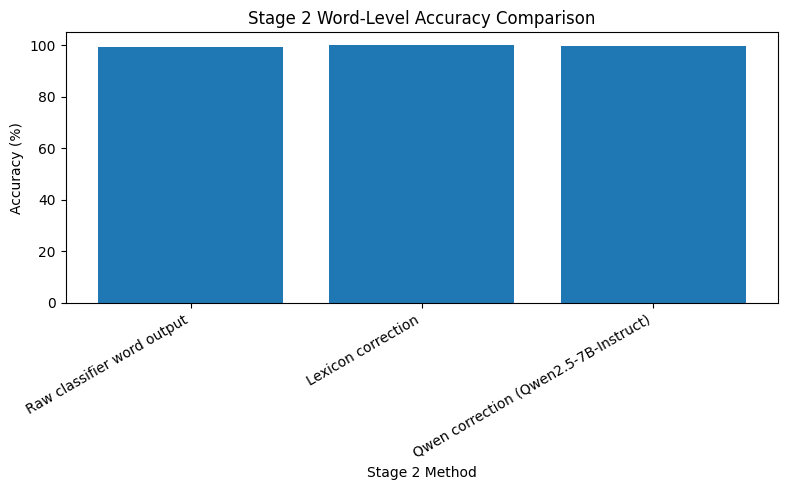

Saved plot:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_method_accuracy_comparison.png


In [32]:
# ============================================================
# Plot Stage 2 Method Accuracy Comparison
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(
    stage2_method_summary_df["method"],
    stage2_method_summary_df["accuracy_percent"]
)
plt.ylabel("Accuracy (%)")
plt.xlabel("Stage 2 Method")
plt.title("Stage 2 Word-Level Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
plt.tight_layout()

method_plot_path = CHAPTER4_DIR / "stage2_method_accuracy_comparison.png"
plt.savefig(method_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:")
print(method_plot_path)

In [33]:
# ============================================================
# Per-word Accuracy Analysis
# ============================================================

agg_dict = {
    "trial": "count",
    "word_length": "first",
    "raw_correct_flag": "mean",
    "lexicon_correct_flag": "mean"
}

if final_stage2_df["qwen_correct_flag"].notna().any():
    agg_dict["qwen_correct_flag"] = "mean"

per_word_df = final_stage2_df.groupby("target_word").agg(agg_dict).reset_index()

per_word_df = per_word_df.rename(columns={
    "trial": "num_trials",
    "raw_correct_flag": "raw_accuracy",
    "lexicon_correct_flag": "lexicon_accuracy",
    "qwen_correct_flag": "qwen_accuracy"
})

# Convert to percentages
for col in ["raw_accuracy", "lexicon_accuracy", "qwen_accuracy"]:
    if col in per_word_df.columns:
        per_word_df[col + "_percent"] = per_word_df[col] * 100

per_word_df = per_word_df.sort_values(by="raw_accuracy", ascending=True)

per_word_path = CHAPTER4_DIR / "stage2_per_word_accuracy.csv"
per_word_df.to_csv(per_word_path, index=False)

display(per_word_df)

print("Saved per-word accuracy:")
print(per_word_path)

,target_word,num_trials,word_length,raw_accuracy,lexicon_accuracy,qwen_accuracy,raw_accuracy_percent,lexicon_accuracy_percent,qwen_accuracy_percent
15,COLLEGE,20,7,0.90,1.0,1.00,90.0,100.0,100.0
56,ORANGE,20,6,0.90,1.0,1.00,90.0,100.0,100.0
18,DINNER,20,6,0.95,1.0,1.00,95.0,100.0,100.0
3,BLACK,20,5,0.95,1.0,1.00,95.0,100.0,100.0
22,EVENING,20,7,0.95,1.0,1.00,95.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...
71,SCIENCE,20,7,1.00,1.0,1.00,100.0,100.0,100.0
95,WINDOW,20,6,1.00,1.0,1.00,100.0,100.0,100.0
96,WORD,20,4,1.00,1.0,0.85,100.0,100.0,85.0
97,WORK,20,4,1.00,1.0,1.00,100.0,100.0,100.0


Saved per-word accuracy:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_per_word_accuracy.csv


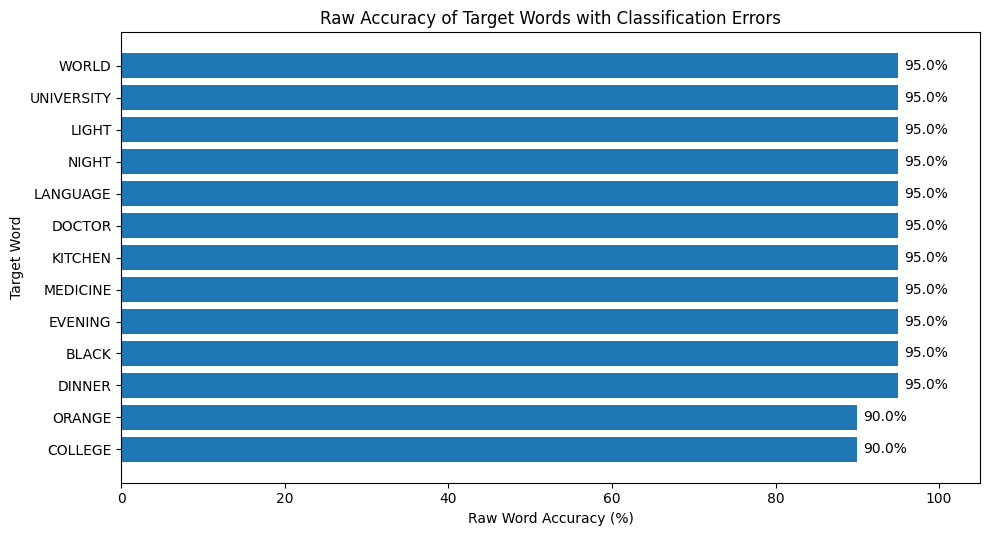

Saved readable error-word plot:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_raw_accuracy_error_words_only.png
Saved error-word table:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_words_with_raw_classification_errors.csv


,target_word,num_trials,word_length,raw_accuracy,lexicon_accuracy,qwen_accuracy,raw_accuracy_percent,lexicon_accuracy_percent,qwen_accuracy_percent
15,COLLEGE,20,7,0.90,1.0,1.00,90.0,100.0,100.0
56,ORANGE,20,6,0.90,1.0,1.00,90.0,100.0,100.0
18,DINNER,20,6,0.95,1.0,1.00,95.0,100.0,100.0
3,BLACK,20,5,0.95,1.0,1.00,95.0,100.0,100.0
22,EVENING,20,7,0.95,1.0,1.00,95.0,100.0,100.0
44,MEDICINE,20,8,0.95,1.0,1.00,95.0,100.0,100.0
38,KITCHEN,20,7,0.95,1.0,1.00,95.0,100.0,100.0
19,DOCTOR,20,6,0.95,1.0,1.00,95.0,100.0,100.0
39,LANGUAGE,20,8,0.95,1.0,1.00,95.0,100.0,100.0
52,NIGHT,20,5,0.95,1.0,0.95,95.0,100.0,95.0


In [34]:
# ============================================================
# Plot Raw Accuracy for Words with Classification Errors Only
# ============================================================

# The complete per-word results remain saved in:
# stage2_per_word_accuracy.csv
#
# For thesis readability, this figure displays only target words
# that had at least one incorrect raw trial.

error_words_df = per_word_df[
    per_word_df["raw_accuracy_percent"] < 100
].copy()

error_words_df = error_words_df.sort_values(
    "raw_accuracy_percent",
    ascending=True
)

error_words_path = (
    CHAPTER4_DIR
    / "stage2_words_with_raw_classification_errors.csv"
)
error_words_df.to_csv(error_words_path, index=False)

if error_words_df.empty:
    print(
        "All target words achieved 100% raw accuracy. "
        "No error-only per-word plot was required."
    )
else:
    figure_height = max(4, 0.42 * len(error_words_df))

    plt.figure(figsize=(10, figure_height))

    bars = plt.barh(
        error_words_df["target_word"],
        error_words_df["raw_accuracy_percent"]
    )

    plt.xlabel("Raw Word Accuracy (%)")
    plt.ylabel("Target Word")
    plt.title(
        "Raw Accuracy of Target Words with Classification Errors"
    )
    plt.xlim(0, 105)

    for bar, accuracy in zip(
        bars,
        error_words_df["raw_accuracy_percent"]
    ):
        plt.text(
            min(accuracy + 0.7, 102),
            bar.get_y() + bar.get_height() / 2,
            f"{accuracy:.1f}%",
            va="center"
        )

    plt.tight_layout()

    per_word_plot_path = (
        CHAPTER4_DIR
        / "stage2_raw_accuracy_error_words_only.png"
    )

    plt.savefig(
        per_word_plot_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    print("Saved readable error-word plot:")
    print(per_word_plot_path)

print("Saved error-word table:")
print(error_words_path)

display(error_words_df)


In [35]:
# ============================================================
# Edit Distance and Character Error Analysis
# ============================================================

def levenshtein_distance(a, b):
    """
    Calculates edit distance between two strings.
    """
    a = str(a)
    b = str(b)

    dp = np.zeros((len(a) + 1, len(b) + 1), dtype=int)

    for i in range(len(a) + 1):
        dp[i, 0] = i

    for j in range(len(b) + 1):
        dp[0, j] = j

    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1

            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return dp[len(a), len(b)]


analysis_df = final_stage2_df.copy()

analysis_df["raw_edit_distance"] = analysis_df.apply(
    lambda row: levenshtein_distance(row["target_word"], row["raw_word"]),
    axis=1
)

analysis_df["lexicon_edit_distance"] = analysis_df.apply(
    lambda row: levenshtein_distance(row["target_word"], row["lexicon_corrected_word"]),
    axis=1
)

if analysis_df["qwen_corrected_word"].notna().any():
    analysis_df["qwen_edit_distance"] = analysis_df.apply(
        lambda row: levenshtein_distance(row["target_word"], row["qwen_corrected_word"]),
        axis=1
    )

analysis_df["raw_character_error_rate"] = analysis_df["raw_edit_distance"] / analysis_df["word_length"]
analysis_df["lexicon_character_error_rate"] = analysis_df["lexicon_edit_distance"] / analysis_df["word_length"]

if "qwen_edit_distance" in analysis_df.columns:
    analysis_df["qwen_character_error_rate"] = analysis_df["qwen_edit_distance"] / analysis_df["word_length"]

edit_summary_rows = [
    {
        "method": "Raw classifier word output",
        "mean_edit_distance": analysis_df["raw_edit_distance"].mean(),
        "mean_character_error_rate": analysis_df["raw_character_error_rate"].mean()
    },
    {
        "method": "Lexicon correction",
        "mean_edit_distance": analysis_df["lexicon_edit_distance"].mean(),
        "mean_character_error_rate": analysis_df["lexicon_character_error_rate"].mean()
    }
]

if "qwen_edit_distance" in analysis_df.columns:
    edit_summary_rows.append({
        "method": "Qwen correction (Qwen2.5-7B-Instruct)",
        "mean_edit_distance": analysis_df["qwen_edit_distance"].mean(),
        "mean_character_error_rate": analysis_df["qwen_character_error_rate"].mean()
    })

edit_summary_df = pd.DataFrame(edit_summary_rows)

edit_detail_path = CHAPTER4_DIR / "stage2_edit_distance_detailed_results.csv"
edit_summary_path = CHAPTER4_DIR / "stage2_edit_distance_summary.csv"

analysis_df.to_csv(edit_detail_path, index=False)
edit_summary_df.to_csv(edit_summary_path, index=False)

display(edit_summary_df)

print("Saved edit distance details:")
print(edit_detail_path)
print("Saved edit distance summary:")
print(edit_summary_path)

,method,mean_edit_distance,mean_character_error_rate
0,Raw classifier word output,0.0075,0.001194
1,Lexicon correction,0.0000,0.000000
2,Qwen correction (Qwen2.5-7B-Instruct),0.0150,0.003450


Saved edit distance details:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_edit_distance_detailed_results.csv
Saved edit distance summary:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_edit_distance_summary.csv


In [36]:
# ============================================================
# Word Length vs Accuracy Analysis
# ============================================================

length_agg = {
    "raw_correct_flag": "mean",
    "lexicon_correct_flag": "mean",
    "target_word": "count"
}

if analysis_df["qwen_correct_flag"].notna().any():
    length_agg["qwen_correct_flag"] = "mean"

length_analysis_df = analysis_df.groupby("word_length").agg(length_agg).reset_index()

length_analysis_df = length_analysis_df.rename(columns={
    "target_word": "num_trials",
    "raw_correct_flag": "raw_accuracy",
    "lexicon_correct_flag": "lexicon_accuracy",
    "qwen_correct_flag": "qwen_accuracy"
})

for col in ["raw_accuracy", "lexicon_accuracy", "qwen_accuracy"]:
    if col in length_analysis_df.columns:
        length_analysis_df[col + "_percent"] = length_analysis_df[col] * 100

length_path = CHAPTER4_DIR / "stage2_word_length_accuracy_analysis.csv"
length_analysis_df.to_csv(length_path, index=False)

display(length_analysis_df)

print("Saved word length analysis:")
print(length_path)

,word_length,raw_accuracy,lexicon_accuracy,num_trials,qwen_accuracy,raw_accuracy_percent,lexicon_accuracy_percent,qwen_accuracy_percent
0,4,1.000000,1.0,220,0.986364,100.000000,100.0,98.636364
1,5,0.993750,1.0,640,0.996875,99.375000,100.0,99.687500
2,6,0.993939,1.0,660,1.000000,99.393939,100.0,100.000000
3,7,0.986667,1.0,300,1.000000,98.666667,100.0,100.000000
4,8,0.985714,1.0,140,1.000000,98.571429,100.0,100.000000
5,9,1.000000,1.0,20,1.000000,100.000000,100.0,100.000000
6,10,0.950000,1.0,20,1.000000,95.000000,100.0,100.000000


Saved word length analysis:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_word_length_accuracy_analysis.csv


In [37]:
# ============================================================
# Correction Improvement Analysis
# ============================================================

improvement_rows = []

raw_wrong = analysis_df[analysis_df["raw_correct_flag"] == 0]

lexicon_fixed = raw_wrong[raw_wrong["lexicon_correct_flag"] == 1]

improvement_rows.append({
    "correction_method": "Lexicon correction",
    "raw_wrong_cases": len(raw_wrong),
    "cases_corrected": len(lexicon_fixed),
    "correction_rate_from_raw_errors": len(lexicon_fixed) / len(raw_wrong) if len(raw_wrong) > 0 else 0
})

if analysis_df["qwen_correct_flag"].notna().any():
    qwen_fixed = raw_wrong[raw_wrong["qwen_correct_flag"] == 1]

    improvement_rows.append({
        "correction_method": "Qwen correction (Qwen2.5-7B-Instruct)",
        "raw_wrong_cases": len(raw_wrong),
        "cases_corrected": len(qwen_fixed),
        "correction_rate_from_raw_errors": len(qwen_fixed) / len(raw_wrong) if len(raw_wrong) > 0 else 0
    })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df["correction_rate_percent"] = improvement_df["correction_rate_from_raw_errors"] * 100

improvement_path = CHAPTER4_DIR / "stage2_correction_improvement_analysis.csv"
improvement_df.to_csv(improvement_path, index=False)

display(improvement_df)

print("Saved correction improvement analysis:")
print(improvement_path)

,correction_method,raw_wrong_cases,cases_corrected,correction_rate_from_raw_errors,correction_rate_percent
0,Lexicon correction,15,15,1.000000,100.000000
1,Qwen correction (Qwen2.5-7B-Instruct),15,13,0.866667,86.666667


Saved correction improvement analysis:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_correction_improvement_analysis.csv


In [38]:
# ============================================================
# Error Examples for Chapter 4 Discussion
# ============================================================

error_columns = [
    "target_word",
    "trial",
    "raw_word",
    "lexicon_corrected_word",
    "qwen_corrected_word",
    "raw_correct_flag",
    "lexicon_correct_flag",
    "qwen_correct_flag",
    "raw_edit_distance",
    "lexicon_edit_distance"
]

if "qwen_edit_distance" in analysis_df.columns:
    error_columns.append("qwen_edit_distance")

available_error_columns = [c for c in error_columns if c in analysis_df.columns]

raw_error_examples_df = analysis_df[analysis_df["raw_correct_flag"] == 0][available_error_columns]

if "raw_edit_distance" in raw_error_examples_df.columns:
    raw_error_examples_df = raw_error_examples_df.sort_values(
        by=["raw_edit_distance", "target_word"],
        ascending=[False, True]
    )

error_examples_path = CHAPTER4_DIR / "stage2_raw_error_examples.csv"
raw_error_examples_df.to_csv(error_examples_path, index=False)

display(raw_error_examples_df.head(30))

print("Saved raw error examples:")
print(error_examples_path)

,target_word,trial,raw_word,lexicon_corrected_word,qwen_corrected_word,raw_correct_flag,lexicon_correct_flag,qwen_correct_flag,raw_edit_distance,lexicon_edit_distance,qwen_edit_distance
1884,BLACK,5,BLACS,BLACK,BLACK,0,1,1,1,0,0
623,COLLEGE,4,COLLERE,COLLEGE,COLLEGE,0,1,1,1,0,0
624,COLLEGE,5,COLLERE,COLLEGE,COLLEGE,0,1,1,1,0,0
1694,DINNER,15,RINNER,DINNER,DINNER,0,1,1,1,0,0
347,DOCTOR,8,ROCTOR,DOCTOR,DOCTOR,0,1,1,1,0,0
1078,EVENING,19,EWENING,EVENING,EVENING,0,1,1,1,0,0
1445,KITCHEN,6,SITCHEN,KITCHEN,KITCHEN,0,1,1,1,0,0
694,LANGUAGE,15,LANGUARE,LANGUAGE,LANGUAGE,0,1,1,1,0,0
1530,LIGHT,11,LIRHT,LIGHT,LIGHT,0,1,1,1,0,0
955,MEDICINE,16,MERICINE,MEDICINE,MEDICINE,0,1,1,1,0,0


Saved raw error examples:
/kaggle/working/stage2_outputs/stage2_chapter4_analysis/stage2_raw_error_examples.csv


In [39]:
# ============================================================
# Export Stage 2 Chapter 4 Analysis Files
# ============================================================

import shutil
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

ZIP_PATH = Path("/kaggle/working") / f"stage2_chapter4_analysis_{timestamp}.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    str(ZIP_PATH).replace(".zip", ""),
    "zip",
    CHAPTER4_DIR
)

print("Created Stage 2 Chapter 4 analysis zip:")
print(ZIP_PATH)
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))

Created Stage 2 Chapter 4 analysis zip:
/kaggle/working/stage2_chapter4_analysis_20260616_120026.zip
Zip size MB: 0.27817344665527344
